# Flow Matching Approaches to Optimization

This notebook demonstrates the same optimization problems from the GMM notebook, but solved using **Flow Matching** (Continuous Normalizing Flows).

Flow Matching learns a vector field that transforms a simple base distribution (e.g., Gaussian) to the target data distribution. For conditional generation, we condition the flow on desired output values.

**Authors:** Victor Alves and John R. Kitchin

## Table of Contents

1. [Setup and Flow Matching Implementation](#setup)
2. [Root Finding](#root-finding)
3. [Optimization with Derivatives](#optimization)
4. [Constrained Optimization](#constrained)
5. [Parameter Estimation](#parameter-estimation)
6. [Mapping Input and Output Spaces](#mapping)

---
<a id='setup'></a>
## 1. Setup and Flow Matching Implementation

We implement a simple Conditional Flow Matching model using PyTorch. The key idea:
- Learn a velocity field $v_\theta(x, t, c)$ that transports samples from noise to data
- Condition on $c$ (the output values we want)
- Generate by integrating the ODE from $t=0$ to $t=1$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import os

# Force CPU for JAX (must be set before importing JAX)
os.environ['JAX_PLATFORMS'] = 'cpu'

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.integrate import solve_ivp
from scipy.stats.qmc import Sobol, scale
from sklearn.cluster import DBSCAN
from tqdm.auto import tqdm

# Force CPU for PyTorch
device = torch.device('cpu')
print(f"Using device: {device}")

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

warnings.filterwarnings('ignore')

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


### 1.1 Flow Matching Model

The velocity network takes:
- `x`: current position (the variables we want to generate)
- `t`: time in [0, 1]
- `c`: conditioning variables (the values we condition on)

In [2]:
class VelocityNetwork(nn.Module):
    """Neural network that predicts velocity field for flow matching."""
    
    def __init__(self, x_dim, c_dim, hidden_dim=128, n_layers=3):
        super().__init__()
        
        self.x_dim = x_dim
        self.c_dim = c_dim
        
        # Input: x, t, c -> output: velocity (same dim as x)
        layers = [nn.Linear(x_dim + 1 + c_dim, hidden_dim), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers.extend([nn.Linear(hidden_dim, hidden_dim), nn.SiLU()])
        layers.append(nn.Linear(hidden_dim, x_dim))
        
        self.net = nn.Sequential(*layers)
    
    def forward(self, x, t, c):
        """Predict velocity at (x, t) conditioned on c."""
        # Ensure t has correct shape
        if t.dim() == 0:
            t = t.unsqueeze(0).expand(x.shape[0], 1)
        elif t.dim() == 1:
            t = t.unsqueeze(1)
        
        # Concatenate inputs
        inp = torch.cat([x, t, c], dim=-1)
        return self.net(inp)

In [ ]:
class ConditionalFlowMatching:
    """Conditional Flow Matching for optimization problems.
    
    Given data (x, y) where x are inputs and y are outputs,
    learns to generate x conditioned on y.
    """
    
    def __init__(self, x_dim, c_dim, hidden_dim=128, n_layers=3, sigma_min=0.01):
        self.x_dim = x_dim
        self.c_dim = c_dim
        self.sigma_min = sigma_min
        
        self.model = VelocityNetwork(x_dim, c_dim, hidden_dim, n_layers).to(device)
        self.optimizer = None
        
        # Store normalization parameters
        self.x_mean = None
        self.x_std = None
        self.c_mean = None
        self.c_std = None
        
        # Store training history
        self.history = {}
    
    def _normalize(self, x, c):
        """Normalize data to zero mean and unit variance."""
        x_norm = (x - self.x_mean) / (self.x_std + 1e-8)
        c_norm = (c - self.c_mean) / (self.c_std + 1e-8)
        return x_norm, c_norm
    
    def _unnormalize_x(self, x_norm):
        """Unnormalize x back to original scale."""
        return x_norm * (self.x_std + 1e-8) + self.x_mean
    
    def fit(self, x_data, c_data, epochs=1000, batch_size=64, lr=1e-3, 
            verbose=True, eval_every=50, n_eval_samples=50):
        """Train the flow matching model.
        
        Parameters
        ----------
        x_data : ndarray, shape (n_samples, x_dim)
            The variables to generate (inputs in optimization context)
        c_data : ndarray, shape (n_samples, c_dim)
            The conditioning variables (outputs in optimization context)
        epochs : int
            Number of training epochs
        batch_size : int
            Batch size for training
        lr : float
            Learning rate
        verbose : bool
            Whether to show progress bar
        eval_every : int
            Evaluate accuracy every N epochs
        n_eval_samples : int
            Number of samples to generate for evaluation
        """
        # Compute normalization parameters
        self.x_mean = torch.tensor(x_data.mean(axis=0), dtype=torch.float32, device=device)
        self.x_std = torch.tensor(x_data.std(axis=0), dtype=torch.float32, device=device)
        self.c_mean = torch.tensor(c_data.mean(axis=0), dtype=torch.float32, device=device)
        self.c_std = torch.tensor(c_data.std(axis=0), dtype=torch.float32, device=device)
        
        # Convert to tensors
        x = torch.tensor(x_data, dtype=torch.float32, device=device)
        c = torch.tensor(c_data, dtype=torch.float32, device=device)
        
        # Normalize
        x, c = self._normalize(x, c)
        
        dataset = TensorDataset(x, c)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        
        # History tracking
        losses = []
        eval_epochs = []
        eval_mae = []
        eval_r2 = []
        
        iterator = tqdm(range(epochs), disable=not verbose, desc="Training")
        
        for epoch in iterator:
            self.model.train()
            epoch_loss = 0.0
            for x_batch, c_batch in loader:
                self.optimizer.zero_grad()
                
                # Sample time uniformly
                t = torch.rand(x_batch.shape[0], 1, device=device)
                
                # Sample noise
                noise = torch.randn_like(x_batch)
                
                # Interpolate: x_t = (1-t) * noise + t * x
                # This is the "optimal transport" path
                x_t = (1 - t) * noise + t * x_batch
                
                # Target velocity: dx/dt = x - noise
                target_v = x_batch - noise
                
                # Predict velocity
                pred_v = self.model(x_t, t, c_batch)
                
                # MSE loss
                loss = ((pred_v - target_v) ** 2).mean()
                
                loss.backward()
                self.optimizer.step()
                
                epoch_loss += loss.item()
            
            avg_loss = epoch_loss / len(loader)
            losses.append(avg_loss)
            
            # Evaluate accuracy periodically
            if (epoch + 1) % eval_every == 0 or epoch == 0:
                mae, r2 = self._evaluate_accuracy(x_data, c_data, n_eval_samples)
                eval_epochs.append(epoch + 1)
                eval_mae.append(mae)
                eval_r2.append(r2)
                
                if verbose:
                    iterator.set_postfix(loss=f"{avg_loss:.4f}", MAE=f"{mae:.4f}", R2=f"{r2:.4f}")
            elif verbose and (epoch + 1) % 100 == 0:
                iterator.set_postfix(loss=f"{avg_loss:.6f}")
        
        # Store history
        self.history = {
            'loss': losses,
            'eval_epochs': eval_epochs,
            'eval_mae': eval_mae,
            'eval_r2': eval_r2
        }
        
        return self.history
    
    def _evaluate_accuracy(self, x_data, c_data, n_samples=50):
        """Evaluate model accuracy on a subset of the data."""
        self.model.eval()
        
        # Sample random conditioning values from training data
        n_test = min(100, len(c_data))
        idx = np.random.choice(len(c_data), n_test, replace=False)
        c_test = c_data[idx]
        x_true = x_data[idx]
        
        # Generate predictions (mean of samples)
        x_pred = self.predict(c_test, n_samples=n_samples)
        
        # Compute metrics
        mae = np.mean(np.abs(x_pred - x_true))
        
        # R² score
        ss_res = np.sum((x_true - x_pred) ** 2)
        ss_tot = np.sum((x_true - np.mean(x_true, axis=0)) ** 2)
        r2 = 1 - ss_res / (ss_tot + 1e-8)
        
        return mae, r2
    
    def plot_learning_curves(self, figsize=(12, 4)):
        """Plot training loss and accuracy curves."""
        if not self.history:
            print("No training history available. Run fit() first.")
            return
        
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        
        # Loss curve
        axes[0].plot(self.history['loss'])
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training Loss')
        axes[0].set_yscale('log')
        axes[0].grid(True, alpha=0.3)
        
        # MAE curve
        axes[1].plot(self.history['eval_epochs'], self.history['eval_mae'], 'o-')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Mean Absolute Error')
        axes[1].set_title('Reconstruction MAE')
        axes[1].grid(True, alpha=0.3)
        
        # R² curve
        axes[2].plot(self.history['eval_epochs'], self.history['eval_r2'], 'o-', color='green')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('R² Score')
        axes[2].set_title('Reconstruction R²')
        axes[2].axhline(1.0, color='k', ls='--', alpha=0.3)
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print final metrics
        print(f"Final Loss: {self.history['loss'][-1]:.6f}")
        print(f"Final MAE:  {self.history['eval_mae'][-1]:.6f}")
        print(f"Final R²:   {self.history['eval_r2'][-1]:.6f}")
    
    @torch.no_grad()
    def sample(self, c_values, n_samples=100, n_steps=50):
        """Generate samples conditioned on c_values.
        
        Parameters
        ----------
        c_values : ndarray, shape (c_dim,) or (n_conditions, c_dim)
            The conditioning values
        n_samples : int
            Number of samples per conditioning value
        n_steps : int
            Number of ODE integration steps
            
        Returns
        -------
        samples : ndarray
        """
        self.model.eval()
        
        c_values = np.atleast_2d(c_values)
        n_conditions = len(c_values)
        
        all_samples = []
        
        for c_val in c_values:
            # Normalize conditioning
            c = torch.tensor(c_val, dtype=torch.float32, device=device)
            c = (c - self.c_mean) / (self.c_std + 1e-8)
            c = c.unsqueeze(0).expand(n_samples, -1)
            
            # Start from noise
            x = torch.randn(n_samples, self.x_dim, device=device)
            
            # Integrate ODE from t=0 to t=1
            dt = 1.0 / n_steps
            for step in range(n_steps):
                t = torch.tensor(step / n_steps, device=device)
                v = self.model(x, t, c)
                x = x + v * dt
            
            # Unnormalize
            x = self._unnormalize_x(x)
            all_samples.append(x.cpu().numpy())
        
        if n_conditions == 1:
            return all_samples[0]
        return all_samples
    
    @torch.no_grad()
    def predict(self, c_values, n_samples=100):
        """Generate samples and return mean prediction."""
        samples = self.sample(c_values, n_samples=n_samples)
        if isinstance(samples, list):
            return np.array([s.mean(axis=0) for s in samples])
        return samples.mean(axis=0)

### 1.2 Utility Functions

In [4]:
def generate_samples(bounds, n_samples=None, method='sobol', seed=42):
    """Generate samples in a bounded region."""
    bounds = np.atleast_2d(bounds)
    n_dims = len(bounds)
    
    if n_samples is None:
        n_samples = 2 ** int(np.ceil(np.log2(20 * n_dims)))
        n_samples = min(n_samples, 4096)
    
    if method == 'sobol':
        sampler = Sobol(d=n_dims, scramble=True, seed=seed)
        n_samples = 2 ** int(np.ceil(np.log2(n_samples)))
        raw = sampler.random(n=n_samples)
    else:
        rng = np.random.default_rng(seed)
        raw = rng.uniform(0, 1, (n_samples, n_dims))
    
    return scale(raw, bounds[:, 0], bounds[:, 1])


def cluster_stats(X, eps=0.5, min_samples=5):
    """Compute statistics for clusters in sampled data."""
    X = np.atleast_2d(X)
    if X.shape[0] == 1:
        X = X.T
    
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
    labels = clustering.labels_
    
    for L in sorted(set(labels)):
        mask = labels == L
        cluster_data = X[mask]
        
        if X.shape[1] == 1:
            mean = np.mean(cluster_data)
            std = np.std(cluster_data)
            print(f'{L:3d}: {mean: 8.4f} +/- {std:.4f} (n={np.sum(mask)})')
        else:
            mean = np.mean(cluster_data, axis=0)
            std = np.std(cluster_data, axis=0)
            print(f'{L:3d}: mean={mean}, std={std} (n={np.sum(mask)})')

---
<a id='root-finding'></a>
## 2. Root Finding

Find values of $x$ where $f(x) = 0$ for the polynomial $y = x^4 - 4x^2 + x + 3$.

Real roots: [-1.92630322 -0.80926547]


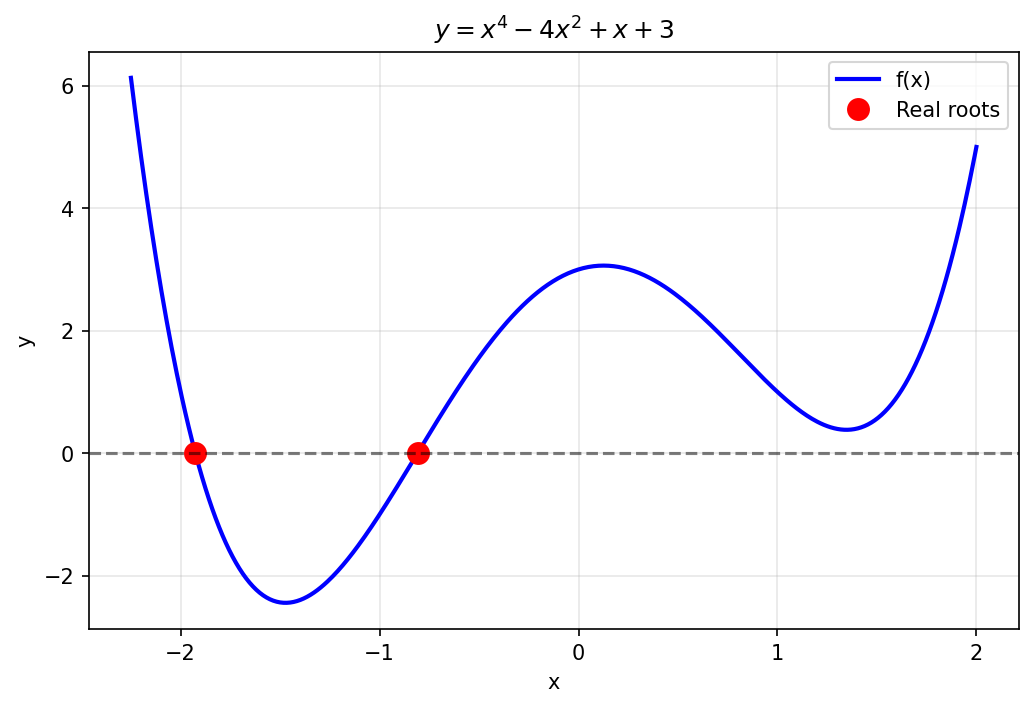

In [5]:
# Generate data
x = np.linspace(-2.25, 2, 500)
y = x**4 - 4*x**2 + x + 3

# True roots
roots = np.roots([1, 0, -4, 1, 3])
real_roots = roots[roots.imag == 0].real
print(f"Real roots: {real_roots}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'b-', lw=2, label='f(x)')
plt.plot(real_roots, [0, 0], 'ro', ms=10, label='Real roots')
plt.axhline(0, color='k', ls='--', alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('$y = x^4 - 4x^2 + x + 3$')
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# Prepare data for flow matching
# x_data: what we want to generate (the input x)
# c_data: what we condition on (the output y)

x_data = x.reshape(-1, 1)
c_data = y.reshape(-1, 1)

print(f"x_data shape: {x_data.shape}")
print(f"c_data shape: {c_data.shape}")

x_data shape: (500, 1)
c_data shape: (500, 1)


In [7]:
# Train flow matching model
fm_root = ConditionalFlowMatching(x_dim=1, c_dim=1, hidden_dim=64, n_layers=3)
losses = fm_root.fit(x_data, c_data, epochs=500, batch_size=64, lr=1e-3)

Training:   0%|          | 0/500 [00:00<?, ?it/s]

In [ ]:
# Plot learning curves (loss, MAE, R²)
fm_root.plot_learning_curves()

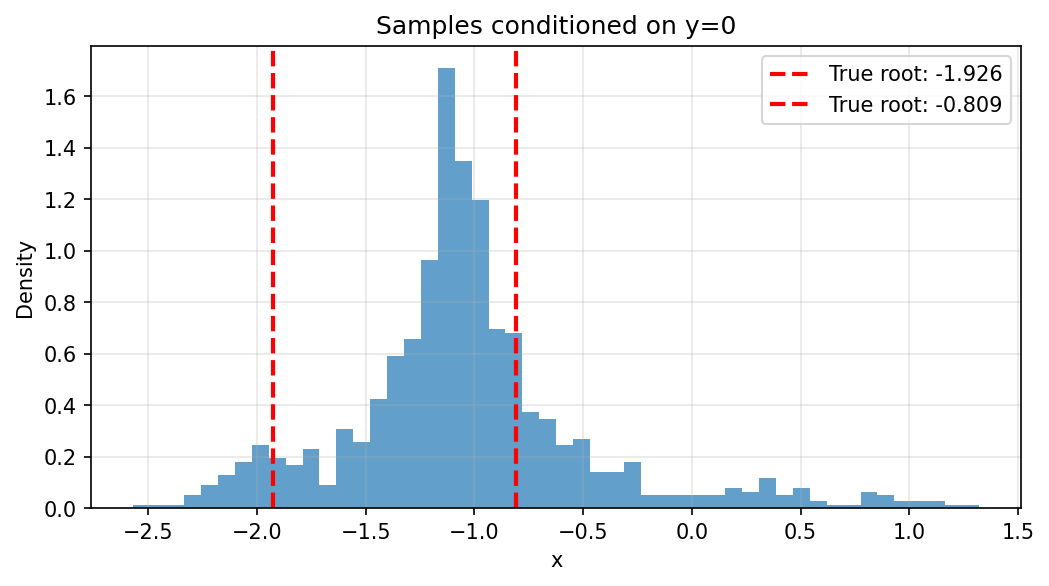


Cluster statistics:
  0:  -1.0381 +/- 0.5662 (n=1000)


In [9]:
# Sample roots by conditioning on y=0
samples = fm_root.sample(c_values=[[0.0]], n_samples=1000, n_steps=50)

plt.figure(figsize=(8, 4))
plt.hist(samples[:, 0], bins=50, density=True, alpha=0.7)
for r in real_roots:
    plt.axvline(r, color='r', ls='--', lw=2, label=f'True root: {r:.3f}')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Samples conditioned on y=0')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nCluster statistics:")
cluster_stats(samples)

In [10]:
# Verify the roots
f_at_samples = samples[:, 0]**4 - 4*samples[:, 0]**2 + samples[:, 0] + 3
print(f"Mean |f(x)| at samples: {np.mean(np.abs(f_at_samples)):.6f}")
print(f"Max |f(x)| at samples: {np.max(np.abs(f_at_samples)):.6f}")

Mean |f(x)| at samples: 1.571439
Max |f(x)| at samples: 17.563354


In [11]:
# Can also condition on other values
samples_y5 = fm_root.sample(c_values=[[5.0]], n_samples=500)

print("Values of x where y=5:")
cluster_stats(samples_y5)

# Verify
f_at_samples = samples_y5[:, 0]**4 - 4*samples_y5[:, 0]**2 + samples_y5[:, 0] + 3
print(f"\nMean y at samples: {np.mean(f_at_samples):.4f} (expected: 5.0)")

Values of x where y=5:
  0:  -0.5177 +/- 1.9831 (n=500)

Mean y at samples: 6.6045 (expected: 5.0)


---
<a id='optimization'></a>
## 3. Optimization with Derivatives

Find stationary points by conditioning on $f'(x) = 0$.

In [12]:
# Generate data with derivatives
x = np.linspace(-2.25, 2, 500)
y = x**4 - 4*x**2 + x + 3
y_prime = 4*x**3 - 8*x + 1

# True stationary points
stationary = np.roots([4, 0, -8, 1])
print(f"Stationary points: {stationary}")

Stationary points: [-1.4729976   1.34699741  0.12600019]


In [13]:
# Train flow matching: generate x conditioned on y'
x_data = x.reshape(-1, 1)
c_data = y_prime.reshape(-1, 1)

fm_opt = ConditionalFlowMatching(x_dim=1, c_dim=1, hidden_dim=64, n_layers=3)
losses = fm_opt.fit(x_data, c_data, epochs=500, batch_size=64)

Training:   0%|          | 0/500 [00:00<?, ?it/s]

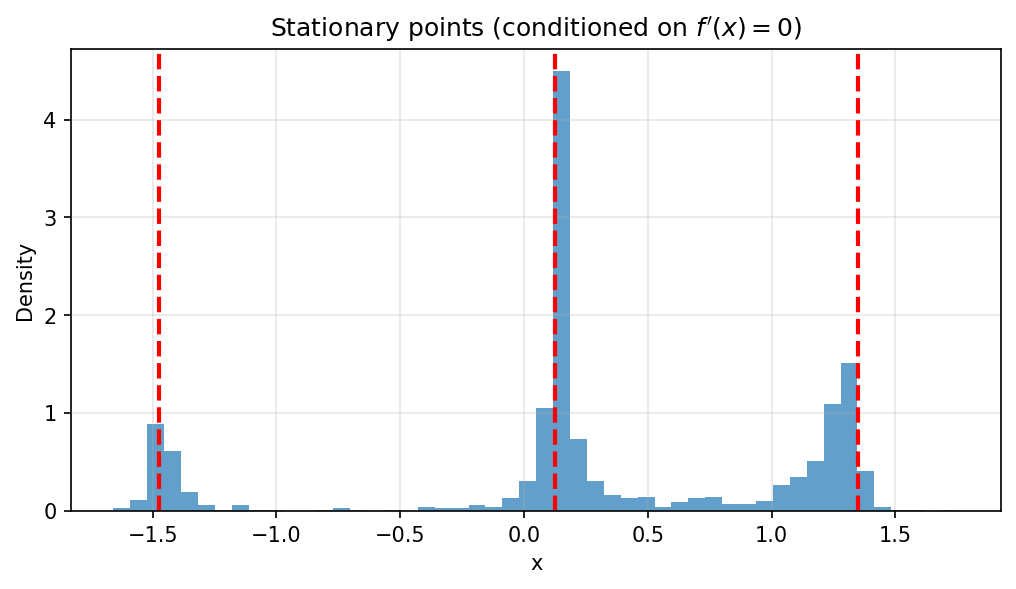

Cluster statistics:
  0:   0.2764 +/- 0.8452 (n=1000)


In [14]:
# Sample stationary points by conditioning on y'=0
samples = fm_opt.sample(c_values=[[0.0]], n_samples=1000)

plt.figure(figsize=(8, 4))
plt.hist(samples[:, 0], bins=50, density=True, alpha=0.7)
for s in stationary:
    plt.axvline(s, color='r', ls='--', lw=2)
plt.xlabel('x')
plt.ylabel('Density')
plt.title("Stationary points (conditioned on $f'(x)=0$)")
plt.grid(True, alpha=0.3)
plt.show()

print("Cluster statistics:")
cluster_stats(samples)

In [15]:
# Distinguish minima from maxima using second derivative sign
y_double_prime_sign = np.where((12 * x**2 - 8) > 0, 1.0, -1.0)

# Condition on both y' and sign(y'')
c_data = np.column_stack([y_prime, y_double_prime_sign])

fm_opt2 = ConditionalFlowMatching(x_dim=1, c_dim=2, hidden_dim=64, n_layers=3)
losses = fm_opt2.fit(x_data, c_data, epochs=500, batch_size=64)

Training:   0%|          | 0/500 [00:00<?, ?it/s]

In [16]:
# Find maximum: y'=0, y''<0 (sign=-1)
samples_max = fm_opt2.sample(c_values=[[0.0, -1.0]], n_samples=500)

print("Maximum (y'=0, y''<0):")
cluster_stats(samples_max)

# Find minima: y'=0, y''>0 (sign=+1)
samples_min = fm_opt2.sample(c_values=[[0.0, 1.0]], n_samples=500)

print("\nMinima (y'=0, y''>0):")
cluster_stats(samples_min)

Maximum (y'=0, y''<0):
  0:   0.1045 +/- 0.0497 (n=500)

Minima (y'=0, y''>0):
  0:  -1.4654 +/- 0.1349 (n=204)
  1:   1.3144 +/- 0.1110 (n=296)


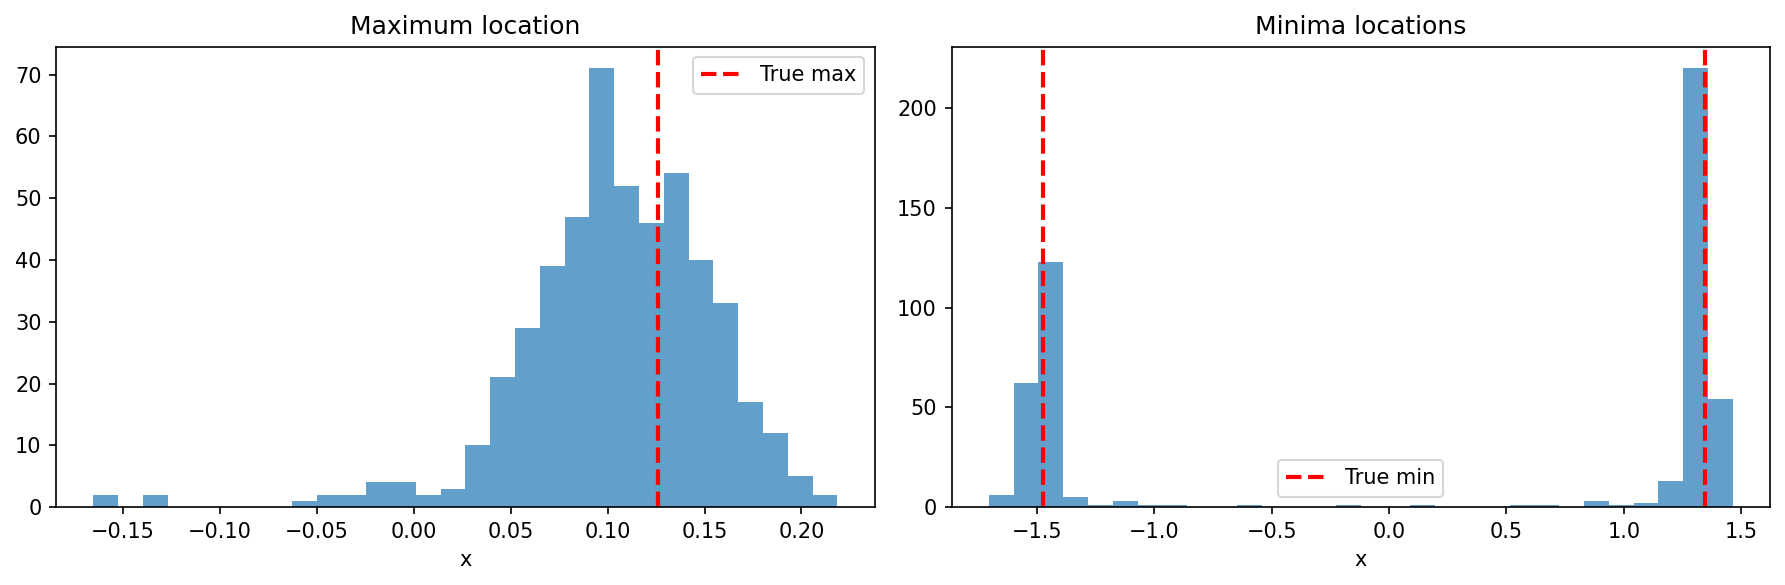

In [17]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(samples_max[:, 0], bins=30, alpha=0.7)
axes[0].axvline(0.126, color='r', ls='--', lw=2, label='True max')
axes[0].set_xlabel('x')
axes[0].set_title('Maximum location')
axes[0].legend()

axes[1].hist(samples_min[:, 0], bins=30, alpha=0.7)
axes[1].axvline(-1.473, color='r', ls='--', lw=2, label='True min')
axes[1].axvline(1.347, color='r', ls='--', lw=2)
axes[1].set_xlabel('x')
axes[1].set_title('Minima locations')
axes[1].legend()

plt.tight_layout()
plt.show()

---
<a id='constrained'></a>
## 4. Constrained Optimization

### 4.1 Equality Constraints (Lagrangian)

Minimize $x^2 + y^2 + z^2$ subject to $2x - y + z = 3$

In [18]:
from scipy.optimize import minimize

# Scipy solution for comparison
def objective(X):
    x, y, z = X
    return x**2 + y**2 + z**2

def eq_constraint(X):
    x, y, z = X
    return 2*x - y + z - 3

sol = minimize(objective, [1, -0.5, 0.5], 
               constraints={'type': 'eq', 'fun': eq_constraint})
print(f"Scipy solution: {sol.x}")
print(f"Objective: {sol.fun}")

Scipy solution: [ 1.  -0.5  0.5]
Objective: 1.5


In [19]:
# Generate data with Lagrangian derivatives
import jax
import jax.numpy as jnp
from jax import jacobian, vmap

def L(Y):
    """Lagrangian: L = f(x) + lambda * g(x)"""
    x, y, z, lam = Y
    f = x**2 + y**2 + z**2
    g = 2*x - y + z - 3
    return f + lam * g

# Sample [x, y, z, lambda]
bounds = [[-2, 2], [-2, 1], [-1, 1], [-2, 2]]
Y = generate_samples(bounds, n_samples=512, seed=42)

# Compute Lagrangian derivatives
dL = vmap(jacobian(L))(Y)
dL = np.array(dL)

print(f"Y shape: {Y.shape}")
print(f"dL shape: {dL.shape}")

Y shape: (512, 4)
dL shape: (512, 4)


In [20]:
# Train: generate [x,y,z,lambda] conditioned on dL = 0
x_data = Y  # [x, y, z, lambda]
c_data = dL  # [dL/dx, dL/dy, dL/dz, dL/dlambda]

fm_lagrange = ConditionalFlowMatching(x_dim=4, c_dim=4, hidden_dim=128, n_layers=4)
losses = fm_lagrange.fit(x_data, c_data, epochs=1000, batch_size=64)

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

In [21]:
# Sample by conditioning on all derivatives = 0
samples = fm_lagrange.sample(c_values=[[0.0, 0.0, 0.0, 0.0]], n_samples=500)

# Get mean solution
x_opt = samples.mean(axis=0)
print(f"Flow Matching solution:")
print(f"  x = {x_opt[0]:.4f}")
print(f"  y = {x_opt[1]:.4f}")
print(f"  z = {x_opt[2]:.4f}")
print(f"  λ = {x_opt[3]:.4f}")
print(f"\nExpected: x=1.0, y=-0.5, z=0.5")

Flow Matching solution:
  x = 0.9993
  y = -0.5088
  z = 0.4998
  λ = -1.0107

Expected: x=1.0, y=-0.5, z=0.5


In [22]:
# Check constraint satisfaction
constraint_vals = 2*samples[:, 0] - samples[:, 1] + samples[:, 2] - 3
print(f"Constraint violation: {np.mean(np.abs(constraint_vals)):.6f}")

Constraint violation: 0.029937


### 4.2 Inequality Constraints (Barrier Method)

Minimize $(x-2)^2 + (y-1)^2$ subject to $x + y \geq 1$

In [23]:
# Scipy solution
def f_ineq(X):
    x, y = X
    return (x - 2)**2 + (y - 1)**2

def c1(X):
    return X[0] + X[1] - 1

sol = minimize(f_ineq, [1, 1], constraints={'type': 'ineq', 'fun': c1})
print(f"Scipy solution: {sol.x}")

Scipy solution: [2.         0.99999999]


In [24]:
# Barrier objective
def barrier_objective(X, mu=1e-7):
    x, y = X
    obj = (x - 2)**2 + (y - 1)**2
    barrier = -mu * jnp.log(x + y - 1)
    return obj + barrier

# Sample feasible region
bounds = [[0, 3], [0, 3]]
inputs = generate_samples(bounds, n_samples=1024, method='uniform', seed=42)

# Filter to feasible
feasible = inputs[:, 0] + inputs[:, 1] > 1.01
inputs = inputs[feasible]

# Compute gradients
outputs = np.array(vmap(jacobian(barrier_objective))(inputs))

print(f"Feasible samples: {len(inputs)}")

Feasible samples: 950


In [25]:
# Train
fm_barrier = ConditionalFlowMatching(x_dim=2, c_dim=2, hidden_dim=64, n_layers=3)
losses = fm_barrier.fit(inputs, outputs, epochs=500, batch_size=64)

Training:   0%|          | 0/500 [00:00<?, ?it/s]

In [26]:
# Sample by conditioning on gradient = 0
samples = fm_barrier.sample(c_values=[[0.0, 0.0]], n_samples=500)

x_opt = samples.mean(axis=0)
print(f"Flow Matching solution: x={x_opt[0]:.4f}, y={x_opt[1]:.4f}")
print(f"Expected: x=2.0, y=1.0")

Flow Matching solution: x=1.9939, y=1.0026
Expected: x=2.0, y=1.0


---
<a id='parameter-estimation'></a>
## 5. Parameter Estimation

Series reaction A → B → C in a plug flow reactor.

In [27]:
from scipy.integrate import solve_ivp

nu = 1
Vf = 2
F0 = [1, 0]

def ode(V, F, k1, k2):
    Fa, Fb = F
    dFadV = -k1 * Fa / nu
    dFbdV = k1 * Fa / nu - k2 * Fb / nu
    return dFadV, dFbdV

# Generate data
bounds = [[0.1, 3], [0.1, 3]]
K = generate_samples(bounds, n_samples=256, seed=42)

data = []
for k1, k2 in K:
    sol = solve_ivp(ode, t_span=(0, Vf), y0=F0, args=(k1, k2))
    Fa, Fb = sol.y[:, -1]
    data.append([k1, k2, Fa, Fb])

data = np.array(data)
print(f"Data shape: {data.shape}")

Data shape: (256, 4)


In [28]:
# Train: generate [k1, k2] conditioned on [Fa, Fb]
x_data = data[:, :2]  # k1, k2
c_data = data[:, 2:]  # Fa, Fb

fm_param = ConditionalFlowMatching(x_dim=2, c_dim=2, hidden_dim=64, n_layers=3)
losses = fm_param.fit(x_data, c_data, epochs=500, batch_size=64)

Training:   0%|          | 0/500 [00:00<?, ?it/s]

In [29]:
# Estimate parameters for two scenarios
observations = [[0.02, 0.05],  # low Fa, low Fb
                [0.02, 0.65]]  # low Fa, high Fb

for i, obs in enumerate(observations):
    samples = fm_param.sample(c_values=[obs], n_samples=500)
    k_est = samples.mean(axis=0)
    k_std = samples.std(axis=0)
    
    # Verify
    Fa_exit, Fb_exit = solve_ivp(ode, t_span=(0, Vf), y0=F0, 
                                  args=(k_est[0], k_est[1])).y[:, -1]
    
    print(f"Scenario {i+1}: Target Fa={obs[0]:.3f}, Fb={obs[1]:.3f}")
    print(f"  Estimated k1 = {k_est[0]:.3f} ± {k_std[0]:.3f}")
    print(f"  Estimated k2 = {k_est[1]:.3f} ± {k_std[1]:.3f}")
    print(f"  Actual: Fa={Fa_exit:.3f}, Fb={Fb_exit:.3f}")
    print()

Scenario 1: Target Fa=0.020, Fb=0.050
  Estimated k1 = 1.997 ± 0.095
  Estimated k2 = 2.497 ± 0.107
  Actual: Fa=0.018, Fb=0.046

Scenario 2: Target Fa=0.020, Fb=0.650
  Estimated k1 = 1.980 ± 0.101
  Estimated k2 = 0.296 ± 0.064
  Actual: Fa=0.019, Fb=0.628



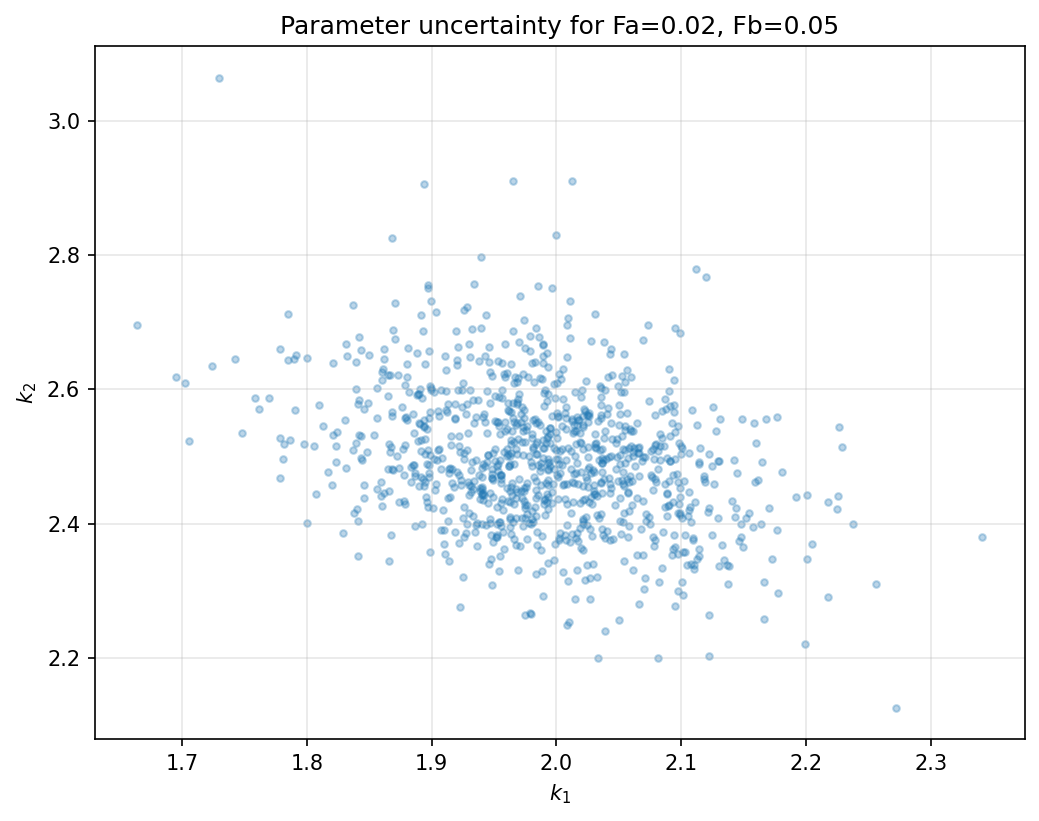

In [30]:
# Visualize uncertainty
samples = fm_param.sample(c_values=[[0.02, 0.05]], n_samples=1000)

plt.figure(figsize=(8, 6))
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.3, s=10)
plt.xlabel('$k_1$')
plt.ylabel('$k_2$')
plt.title('Parameter uncertainty for Fa=0.02, Fb=0.05')
plt.grid(True, alpha=0.3)
plt.show()

---
<a id='mapping'></a>
## 6. Mapping Input and Output Spaces

CSTR design: map desired concentrations (Ca, Cb) to design parameters (R, RT).

In [31]:
# CSTR model
H = 1
vo = 1
Cao = 1

bounds = [[0.1, 3], [0.1, 15]]
X = generate_samples(bounds, n_samples=1024, seed=42)

R, RT = X.T
V = np.pi * R**2 * H
k1 = np.exp(-3 / RT)
k2 = np.exp(-10 / RT)

a = V * k1
b = vo + V * k2
c = -vo * Cao
Ca = (-b + np.sqrt(b**2 - 4*a*c)) / (2*a)
Cb = k1 * Ca**2 * V / vo

print(f"Ca range: [{Ca.min():.3f}, {Ca.max():.3f}]")
print(f"Cb range: [{Cb.min():.3f}, {Cb.max():.3f}]")

Ca range: [0.061, 1.000]
Cb range: [0.000, 0.623]


In [32]:
# Train: generate [R, RT] conditioned on [Ca, Cb]
x_data = np.column_stack([R, RT])
c_data = np.column_stack([Ca, Cb])

fm_map = ConditionalFlowMatching(x_dim=2, c_dim=2, hidden_dim=128, n_layers=4)
losses = fm_map.fit(x_data, c_data, epochs=1000, batch_size=64)

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

In [33]:
# Map desired output region to input space
center = (0.58, 0.3)
radius = 0.08

# Generate points in desired circle
theta = np.random.uniform(0, 2*np.pi, 500)
r = np.sqrt(np.random.uniform(0, 1, 500)) * radius
Ca_desired = center[0] + r * np.cos(theta)
Cb_desired = center[1] + r * np.sin(theta)

# Map to input space
c_values = np.column_stack([Ca_desired, Cb_desired])
mapped = []
for c in c_values:
    s = fm_map.sample(c_values=[c], n_samples=1)
    mapped.append(s[0])
mapped = np.array(mapped)

print(f"Mapped {len(mapped)} points")

Mapped 500 points


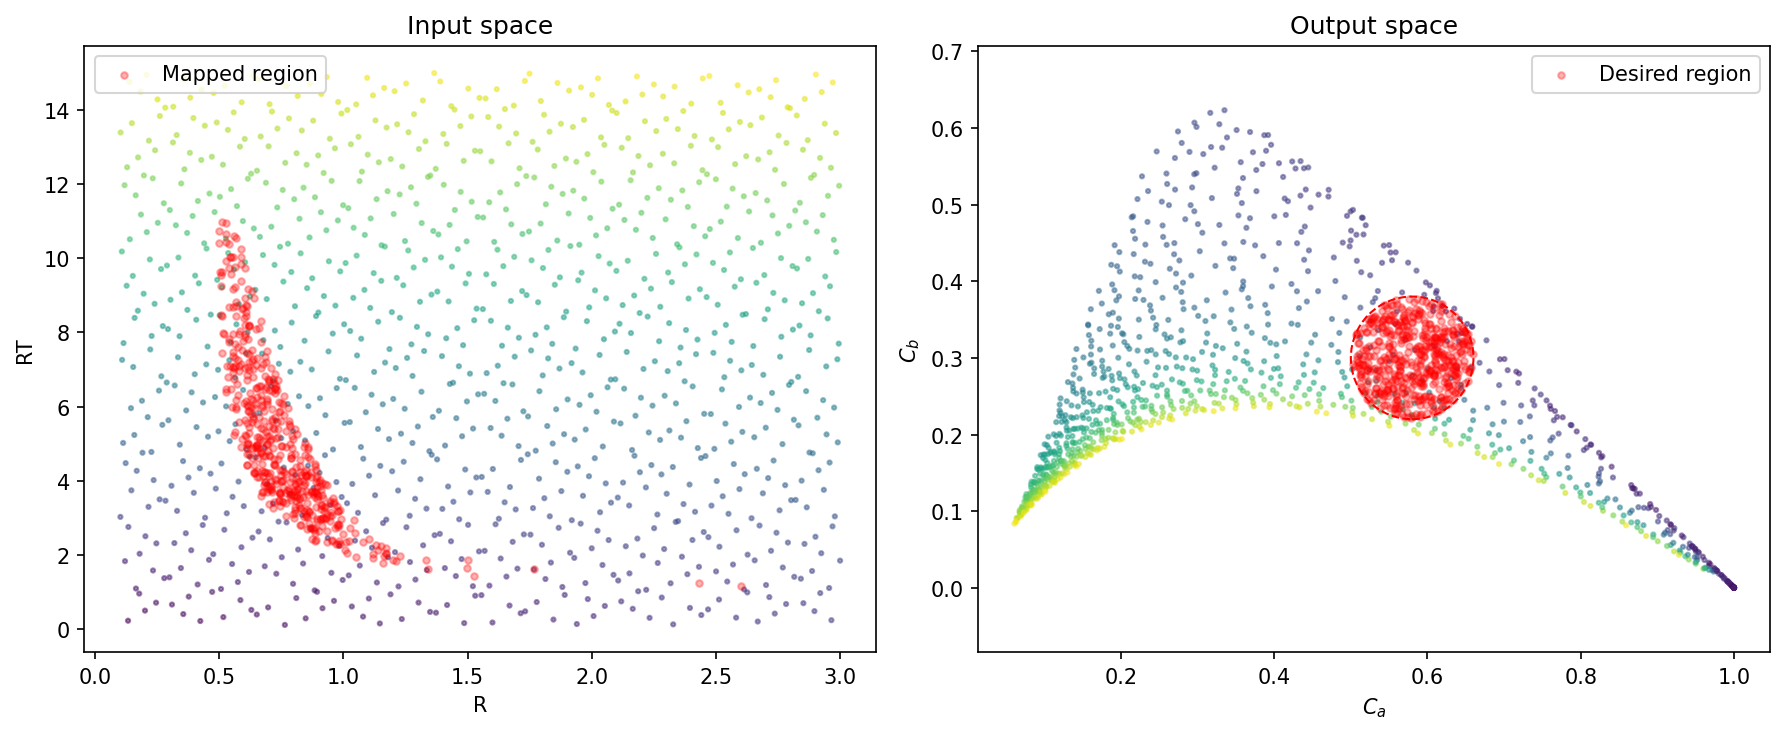

In [34]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = np.sqrt(R**2 + RT**2)

# Input space
axes[0].scatter(R, RT, s=4, c=colors, cmap='viridis', alpha=0.5)
axes[0].scatter(mapped[:, 0], mapped[:, 1], c='red', s=10, alpha=0.3, 
                label='Mapped region')
axes[0].set_xlabel('R')
axes[0].set_ylabel('RT')
axes[0].set_title('Input space')
axes[0].legend()

# Output space
axes[1].scatter(Ca, Cb, s=4, c=colors, cmap='viridis', alpha=0.5)
axes[1].scatter(Ca_desired, Cb_desired, c='red', s=10, alpha=0.3,
                label='Desired region')
circle = plt.Circle(center, radius, fill=False, color='red', ls='--')
axes[1].add_patch(circle)
axes[1].set_xlabel('$C_a$')
axes[1].set_ylabel('$C_b$')
axes[1].set_title('Output space')
axes[1].axis('equal')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Summary

This notebook demonstrated **Flow Matching** (Continuous Normalizing Flows) for optimization:

| Problem | GMM Approach | Flow Matching Approach |
|---------|--------------|------------------------|
| Root finding | Condition on f(x)=0 | Same - condition on f(x)=0 |
| Optimization | Condition on f'(x)=0 | Same - condition on f'(x)=0 |
| Constrained | Lagrangian derivatives | Same - condition on ∇L=0 |
| Parameter est. | Condition on observations | Same - condition on observations |
| Mapping | Condition on output | Same - condition on output |

**Key differences from GMM:**
- Flow Matching learns a continuous transformation (neural ODE)
- More flexible for complex distributions
- Requires more training data and compute
- Can generate smoother samples
- Better scaling to higher dimensions

**Trade-offs:**
- GMM: Fast training, interpretable components, good for low dimensions
- Flow Matching: More expressive, better for complex/high-dim, slower training